In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, accuracy_score

In [47]:
df = pd.read_csv('01_diabetes.csv')
df.sample(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
67,2,109,92,0,0,42.7,0.845,54,0
599,1,109,38,18,120,23.1,0.407,26,0
295,6,151,62,31,120,35.5,0.692,28,0


for splits 30 acc is 0.7922077922077922


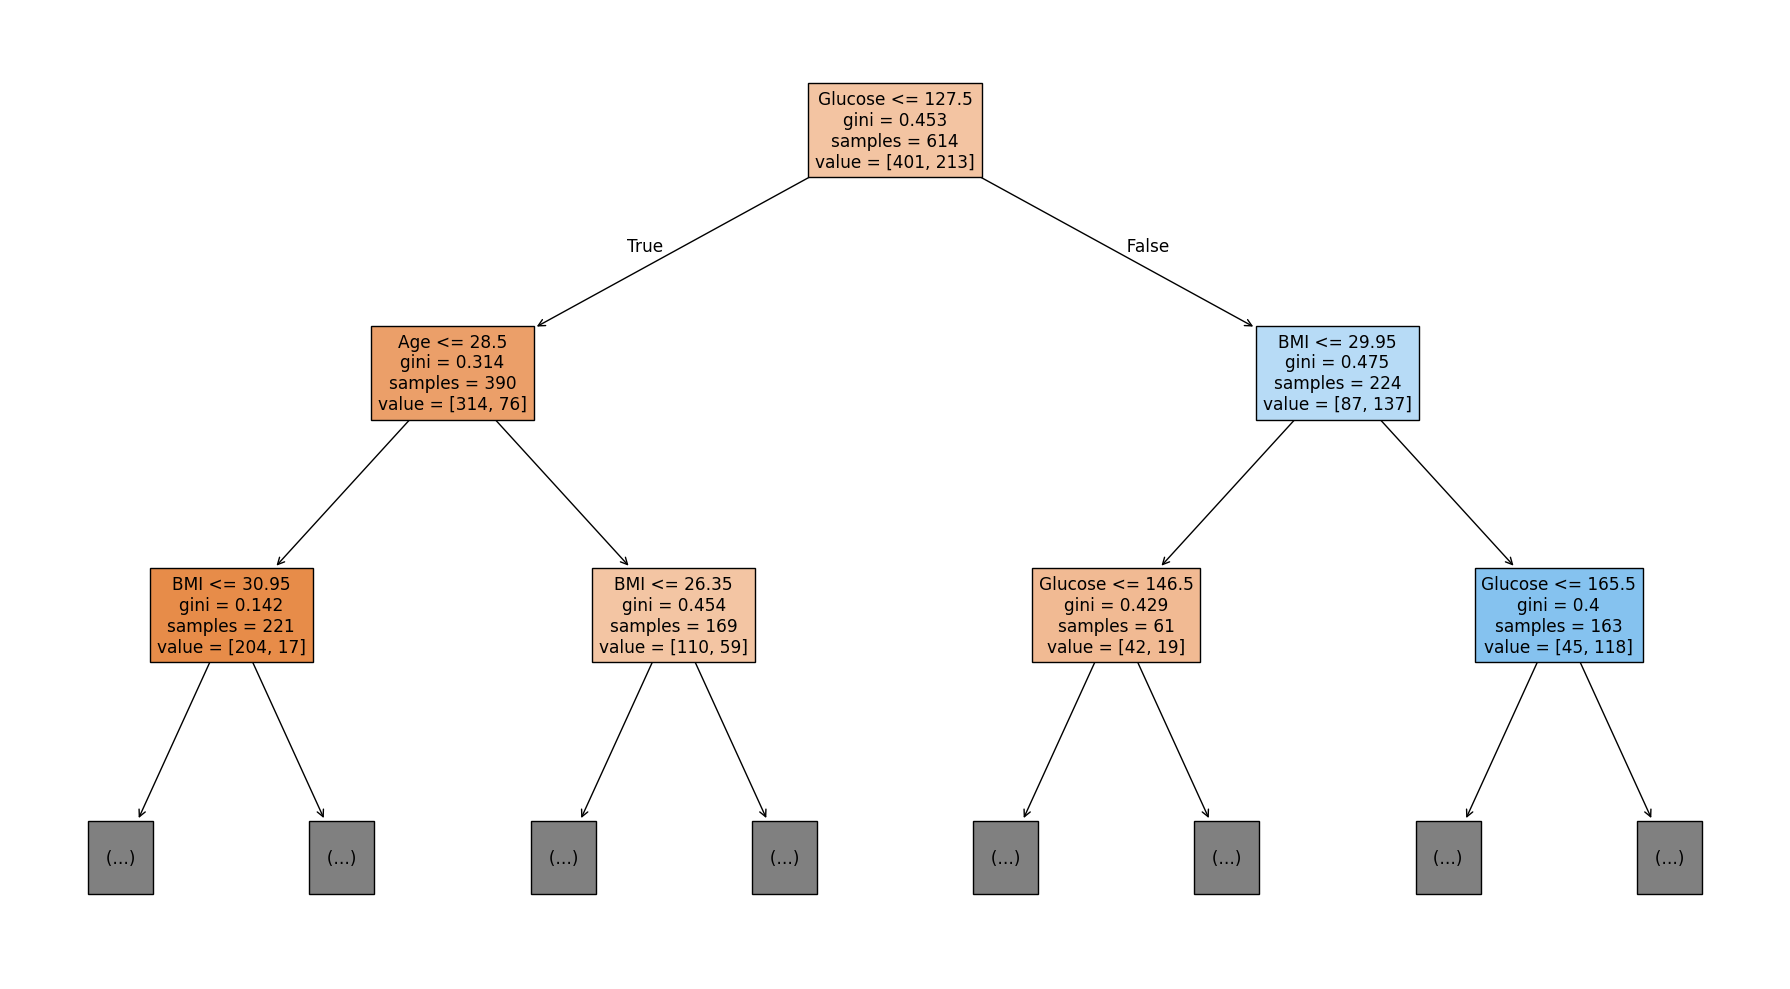

In [55]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
model.fit(X_train, y_train)
    
acc = model.score(X_test, y_test)
print(f'for splits {splits} acc is {acc}')
plt.figure(figsize=(18, 10))
plot_tree(
    model,
    feature_names=X.columns,
    filled=True,
    max_depth=2
)
plt.tight_layout()
plt.show()



In [69]:
full_tree = DecisionTreeClassifier()
full_tree.fit(X_train, y_train)

path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
trees = []

for alpha in ccp_alphas:
    model = model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model, alpha))

best_alpha = 0
best_acc = 0

for model, alpha in trees:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

# print(best_alpha)
print(best_acc)

best_model = DecisionTreeClassifier(max_depth=5, min_samples_split=10, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
print(f'Accuracy is {accuracy_score(y_test, y_pred)}')
print(f'Precision is {precision_score(y_test, y_pred)}')
print(f'Recall is {recall_score(y_test, y_pred)}')
print(f'Accuracy is {best_model.score(X_test, y_test)}')

# print(best_model.min_samples_leaf())

0.7987012987012987
Accuracy is 0.7987012987012987
Precision is 0.7608695652173914
Recall is 0.6363636363636364
Accuracy is 0.7987012987012987
